In [1]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('../..'))

# Now you can import from nn
from nn import network
from nn import mnist_loader

/Users/jakemasaschi/Documents/GitHub/cosc470_2026/nn/network.py:155: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  """Return the vector of partial derivatives \partial C_x /


In [ ]:
import numpy as np

train_data, validation_data, test_data = mnist_loader.load_data_wrapper('../../nn/mnist.pkl.gz')
train_data = list(train_data)
validation_data = list(validation_data)
test_data = list(test_data)

network_one_accuracies = []

net = network.Network([784, 15, 10])
for i in range(30):
    net.SGD(train_data, 1, 10, 0.5, test_data=test_data) #eta=0.5 to reflect slower learning rate
    network_one_accuracies.append(net.evaluate(test_data) / len(test_data))
    print(network_one_accuracies[-1])

network_two_accuracies = []

net = network.Network([784, 16, 16, 10])
for i in range(30):
    net.SGD(train_data, 1, 10, 0.5, test_data=test_data) #eta=0.5 to reflect slower learning rate
    network_two_accuracies.append(net.evaluate(test_data) / len(test_data))
    print(network_two_accuracies[-1])


Epoch 0 : 8072 / 10000 [895/980 1073/1135]
0.8072
Epoch 0 : 8710 / 10000 [927/980 1089/1135]
0.871
Epoch 0 : 8909 / 10000 [934/980 1091/1135]
0.8909
Epoch 0 : 8968 / 10000 [939/980 1105/1135]
0.8968
Epoch 0 : 9052 / 10000 [937/980 1104/1135]
0.9052
Epoch 0 : 9090 / 10000 [941/980 1110/1135]
0.909
Epoch 0 : 9103 / 10000 [936/980 1103/1135]
0.9103
Epoch 0 : 9121 / 10000 [944/980 1093/1135]
0.9121
Epoch 0 : 9152 / 10000 [942/980 1095/1135]
0.9152
Epoch 0 : 9172 / 10000 [945/980 1094/1135]
0.9172
Epoch 0 : 9171 / 10000 [944/980 1100/1135]
0.9171
Epoch 0 : 9211 / 10000 [941/980 1116/1135]
0.9211
Epoch 0 : 9214 / 10000 [952/980 1114/1135]
0.9214
Epoch 0 : 9205 / 10000 [942/980 1114/1135]
0.9205
Epoch 0 : 9222 / 10000 [946/980 1112/1135]
0.9222
Epoch 0 : 9224 / 10000 [944/980 1111/1135]
0.9224
Epoch 0 : 9236 / 10000 [943/980 1110/1135]
0.9236
Epoch 0 : 9237 / 10000 [944/980 1117/1135]
0.9237
Epoch 0 : 9218 / 10000 [950/980 1111/1135]
0.9218
Epoch 0 : 9233 / 10000 [943/980 1115/1135]
0.9233
Ep

In [14]:
# now let's do the digit darkness alg

darknesses = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
darkcnts = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
for i in range(len(train_data)):
    x, y = train_data[i]
    digit = np.argmax(y)
    darknesses[digit] += np.sum(x)
    darkcnts[digit] += 1

print(darknesses)
print(darkcnts)

darkaverages = [darknesses[i] / darkcnts[i] for i in range(10)]
print(darkaverages)

correct = 0
# now let's determine the accuracies on the test set for each digit
for i in range(len(test_data)):
    x, y = test_data[i]
    darkx = np.sum(x)
    digit = np.argmax(y)
    diffs = [abs(darkx - darkaverages[i]) for i in range(10)]
    predicted_digit = np.argmin(diffs)
    if predicted_digit == digit:
        correct += 1

acc = correct / len(test_data)
print(acc)

[np.float32(670105.44), np.float32(338751.56), np.float32(577750.75), np.float32(565552.3), np.float32(462677.4), np.float32(452161.62), np.float32(531654.1), np.float32(465123.3), np.float32(570777.94), np.float32(479075.66)]
[4932, 5678, 4968, 5101, 4859, 4506, 4951, 5175, 4842, 4988]
[np.float32(135.86891), np.float32(59.660366), np.float32(116.29443), np.float32(110.87087), np.float32(95.2207), np.float32(100.346565), np.float32(107.38318), np.float32(89.8789), np.float32(117.880615), np.float32(96.04564)]
0.2322


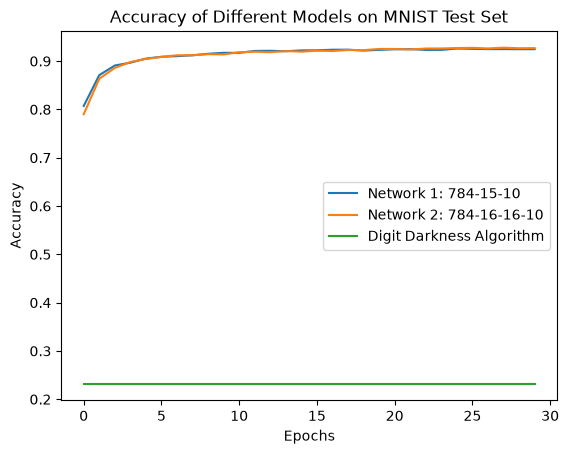

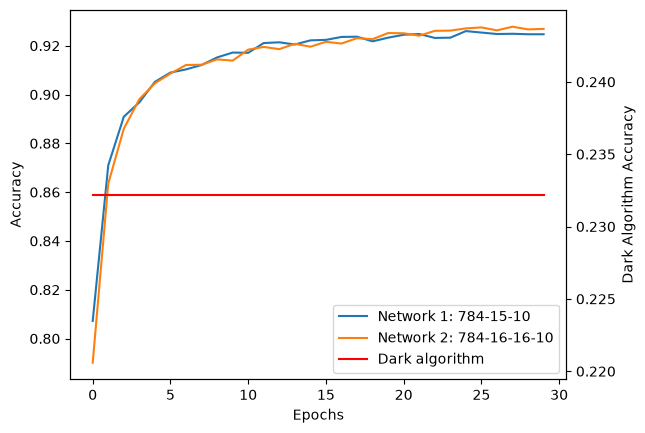

In [15]:
import matplotlib.pyplot as plt

darkaccs = [acc for i in range(30)]

plt.plot(range(30), network_one_accuracies, label='Network 1: 784-15-10')
plt.plot(range(30), network_two_accuracies, label="Network 2: 784-16-16-10")
plt.plot(range(30), darkaccs, label="Digit Darkness Algorithm")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models on MNIST Test Set')
plt.legend()
plt.show()

#closer look
fig, ax1=plt.subplots()
ax1.plot(range(30), network_one_accuracies, label='Network 1: 784-15-10')
ax1.plot(range(30), network_two_accuracies, label="Network 2: 784-16-16-10")
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')

ax2 = ax1.twinx()
ax2.plot(range(30), darkaccs, label="Dark algorithm", color='red')
ax2.set_ylabel('Dark Algorithm Accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.show()